In [3]:
import numpy as np
import pandas as pd
from datetime import datetime

In [4]:
df = pd.read_csv("Visa_Dataset.csv")

print("Original DataFrame with Missing Values:\n", df)


Original DataFrame with Missing Values:
      application_date decision_date    country visa_type processing_office
0          23-11-2024    12-12-2024      India      Work          New York
1          24-04-2024    16-05-2024  Australia   Student            Sydney
2          06-10-2024    22-10-2024    Germany  Business             Delhi
3          16-01-2024    01-02-2024        USA   Tourist            Berlin
4          04-11-2024    12-11-2024    Germany   Tourist            Sydney
...               ...           ...        ...       ...               ...
9995       23-03-2024    13-05-2024        USA   Student          New York
9996       15-02-2024    19-03-2024      India   Student           Toronto
9997       27-08-2024    12-11-2024         UK      Work          New York
9998       27-09-2024    25-01-2025  Australia   Tourist          New York
9999       16-07-2024    22-09-2024  Australia   Student             Delhi

[10000 rows x 5 columns]


In [5]:
miss = df.isnull().sum()
print("\nMissing values count:\n", miss)


Missing values count:
 application_date     5
decision_date        5
country              5
visa_type            3
processing_office    2
dtype: int64


In [6]:
df["application_date"].fillna(df["application_date"].mode()[0], inplace=True)
df["decision_date"].fillna(df["decision_date"].mode()[0], inplace=True)


In [7]:
df["country"].fillna("Unknown", inplace=True)
df["processing_office"].fillna("Unknown", inplace=True)

In [8]:
df["application_date"] = pd.to_datetime(df["application_date"], dayfirst=True)
df["decision_date"] = pd.to_datetime(df["decision_date"], dayfirst=True)

In [9]:
print("\nAfter handling missing values:\n", df)


After handling missing values:
      application_date decision_date    country visa_type processing_office
0          2024-11-23    2024-12-12      India      Work          New York
1          2024-04-24    2024-05-16  Australia   Student            Sydney
2          2024-10-06    2024-10-22    Germany  Business             Delhi
3          2024-01-16    2024-02-01        USA   Tourist            Berlin
4          2024-11-04    2024-11-12    Germany   Tourist            Sydney
...               ...           ...        ...       ...               ...
9995       2024-03-23    2024-05-13        USA   Student          New York
9996       2024-02-15    2024-03-19      India   Student           Toronto
9997       2024-08-27    2024-11-12         UK      Work          New York
9998       2024-09-27    2025-01-25  Australia   Tourist          New York
9999       2024-07-16    2024-09-22  Australia   Student             Delhi

[10000 rows x 5 columns]


In [10]:
df["processing_days"] = (df["decision_date"] - df["application_date"]).dt.days

print("\nAfter calculating processing days:\n", df)



After calculating processing days:
      application_date decision_date    country visa_type processing_office  \
0          2024-11-23    2024-12-12      India      Work          New York   
1          2024-04-24    2024-05-16  Australia   Student            Sydney   
2          2024-10-06    2024-10-22    Germany  Business             Delhi   
3          2024-01-16    2024-02-01        USA   Tourist            Berlin   
4          2024-11-04    2024-11-12    Germany   Tourist            Sydney   
...               ...           ...        ...       ...               ...   
9995       2024-03-23    2024-05-13        USA   Student          New York   
9996       2024-02-15    2024-03-19      India   Student           Toronto   
9997       2024-08-27    2024-11-12         UK      Work          New York   
9998       2024-09-27    2025-01-25  Australia   Tourist          New York   
9999       2024-07-16    2024-09-22  Australia   Student             Delhi   

      processing_days  
0 

In [11]:
df_encoded = pd.get_dummies(df, columns=["country", "visa_type", "processing_office"])

print("\nEncoded DataFrame:\n", df_encoded)


Encoded DataFrame:
      application_date decision_date  processing_days  country_Australia  \
0          2024-11-23    2024-12-12               19              False   
1          2024-04-24    2024-05-16               22               True   
2          2024-10-06    2024-10-22               16              False   
3          2024-01-16    2024-02-01               16              False   
4          2024-11-04    2024-11-12                8              False   
...               ...           ...              ...                ...   
9995       2024-03-23    2024-05-13               51              False   
9996       2024-02-15    2024-03-19               33              False   
9997       2024-08-27    2024-11-12               77              False   
9998       2024-09-27    2025-01-25              120               True   
9999       2024-07-16    2024-09-22               68               True   

      country_Canada  country_Germany  country_India  country_UK  country_USA 

In [12]:
# -------------------------------
# Milestone 2 (EDA) & (feature engineering)
# -------------------------------


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
print("\nStatistical Summary:\n", df["processing_days"].describe())


Statistical Summary:
 count    10000.000000
mean        62.533000
std         34.106581
min       -223.000000
25%         33.000000
50%         62.000000
75%         92.000000
max        318.000000
Name: processing_days, dtype: float64


In [15]:
df = df[df["processing_days"] >= 0]

In [16]:
df = df[df["processing_days"] <= 150]

C:\New folder\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


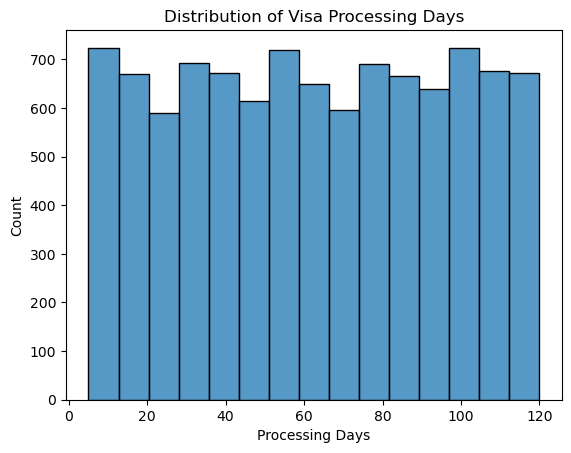

In [17]:
sns.histplot(df["processing_days"], bins=15)
plt.title("Distribution of Visa Processing Days")
plt.xlabel("Processing Days")
plt.ylabel("Count")
plt.show()

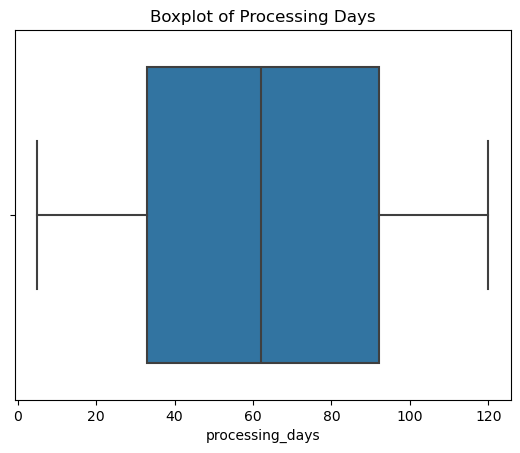

In [18]:
sns.boxplot(x=df["processing_days"])
plt.title("Boxplot of Processing Days")
plt.show()

In [19]:
df["application_month"] = df["application_date"].dt.month


Correlation Matrix:
                    processing_days  application_month
processing_days           1.000000           0.002465
application_month         0.002465           1.000000


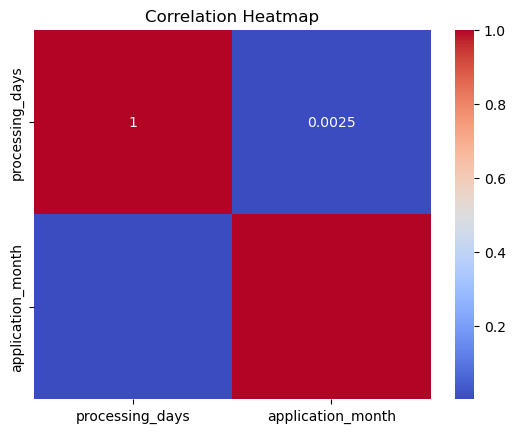

In [20]:
corr_matrix = df[["processing_days", "application_month"]].corr()
print("\nCorrelation Matrix:\n", corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

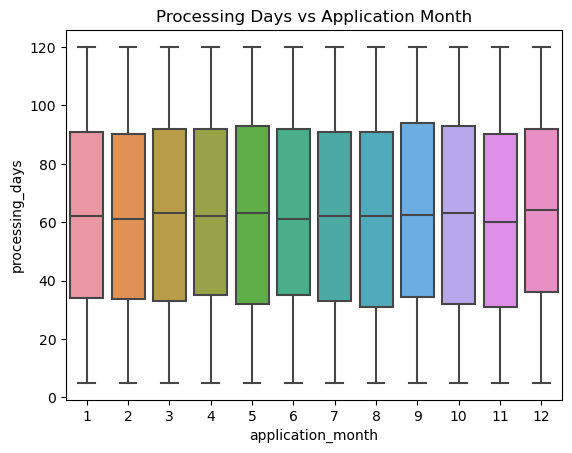

In [21]:


sns.boxplot(x="application_month", y="processing_days", data=df)
plt.title("Processing Days vs Application Month")
plt.show()